In [1]:
!pip install pyspark vaderSentiment -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, warnings, joblib
warnings.filterwarnings('ignore')

print("All libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
All libraries ready


In [3]:
from google.colab import files
uploaded = files.upload()
# A button will appear — click it and select reviews_clean.csv from your computer

Saving reviews_clean.csv to reviews_clean.csv


In [4]:
df = pd.read_csv('reviews_clean.csv')
df['Text'] = df['Text'].astype(str)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (524587, 16)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'year', 'month', 'sentiment', 'sentiment_label', 'text_length', 'word_count']

First 3 rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,year,month,sentiment,sentiment_label,text_length,word_count
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011,4,positive,1,263,48
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,2012,9,negative,0,190,31
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,2008,8,positive,1,509,94


In [5]:
# Text features
df['text_length']    = df['Text'].apply(len)
df['word_count']     = df['Text'].apply(lambda x: len(x.split()))
df['avg_word_len']   = df['Text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df['sentence_count'] = df['Text'].apply(
    lambda x: len([s for s in x.split('.') if s.strip()]))
df['exclamations']   = df['Text'].apply(lambda x: x.count('!'))
df['questions']      = df['Text'].apply(lambda x: x.count('?'))
df['caps_ratio']     = df['Text'].apply(
    lambda x: sum(1 for c in x if c.isupper())/len(x) if len(x) > 0 else 0)

# Summary feature — safe check
if 'Summary' in df.columns:
    df['has_summary'] = df['Summary'].apply(
        lambda x: int(len(str(x).strip()) > 0) if pd.notnull(x) else 0)
else:
    df['has_summary'] = 0
    print("No Summary column — set has_summary=0")

# Helpfulness feature — safe check
if 'HelpfulnessNumerator' in df.columns and 'HelpfulnessDenominator' in df.columns:
    df['helpfulness_ratio'] = df.apply(
        lambda r: r['HelpfulnessNumerator'] / r['HelpfulnessDenominator']
        if r['HelpfulnessDenominator'] > 0 else 0, axis=1)
else:
    df['helpfulness_ratio'] = 0
    print("No helpfulness columns — set helpfulness_ratio=0")

# Time features — safe check
if 'Time' in df.columns:
    df['Time']        = pd.to_datetime(df['Time'], errors='coerce')
    df['day_of_week'] = df['Time'].dt.dayofweek
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    df['quarter']     = df['Time'].dt.quarter
elif 'year' in df.columns:
    df['day_of_week'] = 0
    df['is_weekend']  = 0
    df['quarter']     = 0
    print("No Time column — using existing year/month columns")
else:
    df['year']        = 2020
    df['month']       = 1
    df['day_of_week'] = 0
    df['is_weekend']  = 0
    df['quarter']     = 0

print("Features created successfully")
print("Shape:", df.shape)

Features created successfully
Shape: (524587, 26)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             f1_score, accuracy_score)

# Sample for speed if dataset is large
df_model = df.sample(n=50000, random_state=42) if len(df) > 50000 else df.copy()
X = df_model['Text']
y = df_model['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Class balance:", y_train.value_counts(normalize=True).round(3).to_dict())

# Model 1 — Logistic Regression
print("\nTraining Logistic Regression...")
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                               stop_words='english', sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1, random_state=42))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:,1]
print("LR done — F1:", round(f1_score(y_test, y_pred_lr), 4))

# Model 2 — Naive Bayes
print("Training Naive Bayes...")
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                               stop_words='english')),
    ('clf',   MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)
y_prob_nb = pipe_nb.predict_proba(X_test)[:,1]
print("NB done — F1:", round(f1_score(y_test, y_pred_nb), 4))

# Model 3 — Random Forest
print("Training Random Forest...")
pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf = pipe_rf.predict_proba(X_test)[:,1]
print("RF done — F1:", round(f1_score(y_test, y_pred_rf), 4))

# Comparison table
results_df = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'F1':       f1_score(y_test, y_pred_lr),
        'AUC-ROC':  roc_auc_score(y_test, y_prob_lr)
    },
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'F1':       f1_score(y_test, y_pred_nb),
        'AUC-ROC':  roc_auc_score(y_test, y_prob_nb)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'F1':       f1_score(y_test, y_pred_rf),
        'AUC-ROC':  roc_auc_score(y_test, y_prob_rf)
    }
}).T.round(4).sort_values('F1', ascending=False)

print("\n=== MODEL COMPARISON ===")
print(results_df)

Train: 40000 | Test: 10000
Class balance: {1: 0.844, 0: 0.156}

Training Logistic Regression...
LR done — F1: 0.9528
Training Naive Bayes...
NB done — F1: 0.9339
Training Random Forest...
RF done — F1: 0.9439

=== MODEL COMPARISON ===
                     Accuracy      F1  AUC-ROC
Logistic Regression    0.9176  0.9528   0.9520
Random Forest          0.9005  0.9439   0.9264
Naive Bayes            0.8813  0.9339   0.9390


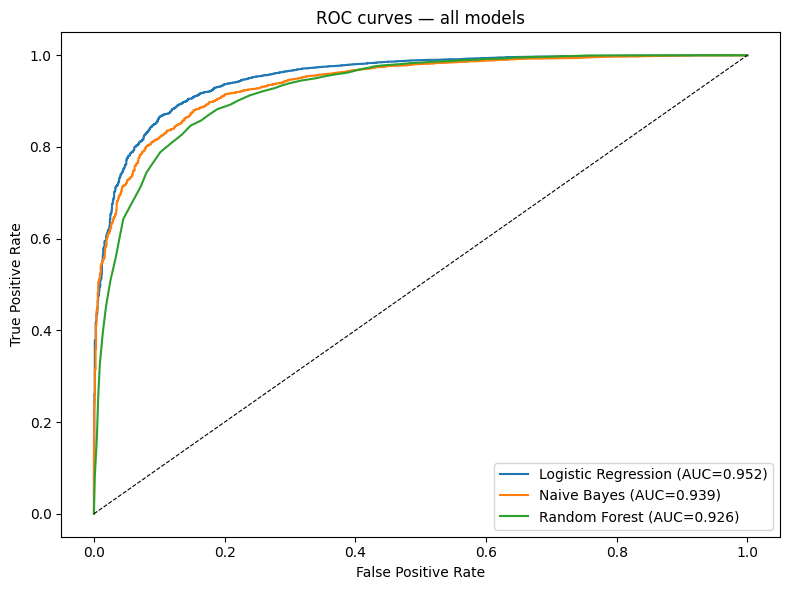

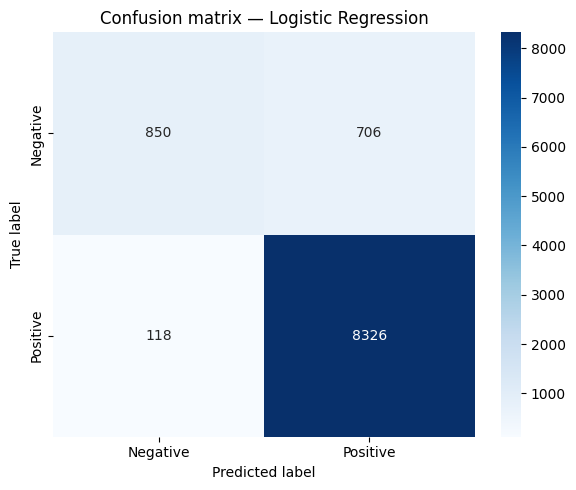

=== CLASSIFICATION REPORT — LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    Negative       0.88      0.55      0.67      1556
    Positive       0.92      0.99      0.95      8444

    accuracy                           0.92     10000
   macro avg       0.90      0.77      0.81     10000
weighted avg       0.92      0.92      0.91     10000



In [9]:
# ROC curves
plt.figure(figsize=(8,6))
for name, y_prob in [('Logistic Regression', y_prob_lr),
                     ('Naive Bayes',         y_prob_nb),
                     ('Random Forest',       y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — all models')
plt.legend()
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150)
plt.show()

# Confusion matrix — best model
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion matrix — Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()

# Detailed report
print("=== CLASSIFICATION REPORT — LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['Negative','Positive']))